In [13]:
import os
import re
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder
from catboost import CatBoostRegressor



warnings.filterwarnings('ignore')

In [14]:
# --------------------------------------------------
# 1. CẤU HÌNH ĐƯỜNG DẪN & ĐỌC DỮ LIỆU
# --------------------------------------------------
CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.dirname(CURRENT_DIR) if 'notebooks' in CURRENT_DIR else CURRENT_DIR

RAW_DATA_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'DuLieuGiaNhaHCM2024.csv')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'models', 'best_model.pkl')

print("Đường dẫn file dữ liệu:", RAW_DATA_PATH)
print("Đường dẫn lưu mô hình:", MODEL_SAVE_PATH)

if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại: {RAW_DATA_PATH}")

try:
    df = pd.read_csv(RAW_DATA_PATH, sep=None, engine='python', encoding='utf-16')
except Exception:
    df = pd.read_csv(RAW_DATA_PATH, sep=None, engine='python', encoding='utf-8-sig')

print("Đã tải dữ liệu thành công!")
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
display(df.head())


Đường dẫn file dữ liệu: d:\05. CODE\DoAnNganh\RealEstateTrading\ml\data\raw\DuLieuGiaNhaHCM2024.csv
Đường dẫn lưu mô hình: d:\05. CODE\DoAnNganh\RealEstateTrading\ml\models\best_model.pkl
Đã tải dữ liệu thành công!
Số dòng: 11780, Số cột: 10


,Address,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,2.0,2.0,3.0,Have certificate,Full,5.35
1,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,2.0,4.0,4.0,Have certificate,Full,6.90
2,"Đường Phạm Văn Chiêu, Phường 14, Gò Vấp, Hồ Ch...",30.0,NaN,NaN,2.0,2.0,2.0,Have certificate,Full,3.79
3,"Đường Quang Trung, Phường 12, Gò Vấp, Hồ Chí Minh",46.0,4.6,6.0,4.0,4.0,5.0,Have certificate,Full,7.99
4,"Đường Ngô Tất Tố, Phường 22, Bình Thạnh, Hồ Ch...",60.0,3.5,5.0,2.0,6.0,5.0,Have certificate,Full,5.60


In [15]:
# --------------------------------------------------
# 2. LÀM SẠCH DỮ LIỆU
# --------------------------------------------------
# Giữ nhiều dữ liệu hơn: chỉ loại bỏ các hàng có target không hợp lệ hoặc giá trị vô hạn rõ ràng.
df = df.replace([np.inf, -np.inf], np.nan)

before_dup = df.shape[0]
df = df.drop_duplicates()
print(f"\nLoại trùng lặp: {before_dup} -> {df.shape[0]} dòng")

TARGET_COL = 'Price'

y_raw = pd.to_numeric(df[TARGET_COL], errors='coerce')
valid_idx = y_raw.notna() & (y_raw > 0)
df = df.loc[valid_idx].copy()
df[TARGET_COL] = y_raw.loc[valid_idx]

# Làm sạch cột đặc trưng một cách nhẹ nhàng để không mất quá nhiều dữ liệu.
for col in df.columns:
    if col == TARGET_COL:
        continue

    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors='coerce')
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    else:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip()
        df[col] = df[col].replace({'': 'Unknown'})


def extract_district(address):
    address = str(address).strip()
    parts = [p.strip() for p in address.split(',')]
    parts = [p for p in parts if p]

    if len(parts) >= 2:
        district = parts[-2]
    else:
        district = parts[-1] if parts else 'Unknown'

    district = re.sub(r'[.\s]+$', '', district).strip()
    return district

if 'Address' in df.columns:
    df['District'] = df['Address'].apply(extract_district)
    df = df.drop(columns=['Address'])

    print(f"\nSố lượng Quận/Huyện khác nhau: {df['District'].nunique()}")
    print(df['District'].value_counts())

    district_counts = df['District'].value_counts()
    rare_districts = district_counts[district_counts < 10].index
    if len(rare_districts) > 0:
        print(f"\nGộp {len(rare_districts)} quận/huyện có < 10 mẫu vào nhóm 'Khác'")
        df['District'] = df['District'].replace(rare_districts, 'Khác')
        print(df['District'].value_counts())

# Chỉ loại bỏ outlier cực đoan, không xoá quá nhiều hàng.
q1 = df[TARGET_COL].quantile(0.01)
q99 = df[TARGET_COL].quantile(0.99)
before_outlier = df.shape[0]
df = df[(df[TARGET_COL] >= q1) & (df[TARGET_COL] <= q99)].copy()
print(f"\nLoại outlier cực đoan: {before_outlier} -> {df.shape[0]} dòng")
print(f"Khoảng giá giữ lại: [{q1:,.0f}, {q99:,.0f}]")



Loại trùng lặp: 11780 -> 11771 dòng

Số lượng Quận/Huyện khác nhau: 31
District
Gò Vấp                       1371
Bình Tân                     1156
Thủ Đức                      1145
Tân Phú                      1015
Quận 12                       940
Bình Thạnh                    851
Tân Bình                      850
Quận 9                        713
Quận 7                        642
Quận 8                        446
Phú Nhuận                     375
Nhà Bè                        359
Quận 10                       291
Quận 6                        246
Hóc Môn                       244
Quận 3                        222
Bình Chánh                    207
Quận 2                        196
Quận 4                        139
Quận 11                       136
Quận 1                        104
Quận 5                         60
Củ Chi                         43
Thành phố Thủ Đức               9
Quận Bình Tân                   4
Quận Tân Bình                   2
Huyện Cần Giờ                   1
Q

In [16]:
# --------------------------------------------------
# 3. FEATURE ENGINEERING (TỐI ƯU LOGIC THỰC TẾ)
# --------------------------------------------------
if 'Frontage' in df.columns and 'Area' in df.columns:
    # Tỷ lệ mặt tiền / diện tích (không cộng 1 vào Area vì diện tích luôn > 0)
    df['Frontage_Area_Ratio'] = df['Frontage'] / np.where(df['Area'] == 0, np.nan, df['Area'])
    df['Frontage_Area_Ratio'] = df['Frontage_Area_Ratio'].fillna(0)

if 'Bedrooms' in df.columns and 'Bathrooms' in df.columns:
    df['Total_Bed_Bath'] = df['Bedrooms'] + df['Bathrooms']
    
    if 'Floors' in df.columns:
        # Nếu Floors = 0 (nhà trệt), quy về 1 tầng để tránh chia cho 0
        floors_corrected = np.where(df['Floors'] < 1, 1, df['Floors'])
        df['Rooms_per_Floor'] = df['Total_Bed_Bath'] / floors_corrected


--- Mức độ tương quan với Price ---
Price                  1.000000
Total_Bed_Bath         0.412692
Bathrooms              0.399080
Bedrooms               0.382088
Area                   0.359463
Floors                 0.348967
District_Encoded       0.275184
Access Road            0.222358
Rooms_per_Floor        0.069496
Frontage               0.065971
Frontage_Area_Ratio   -0.291141
Name: Price, dtype: float64


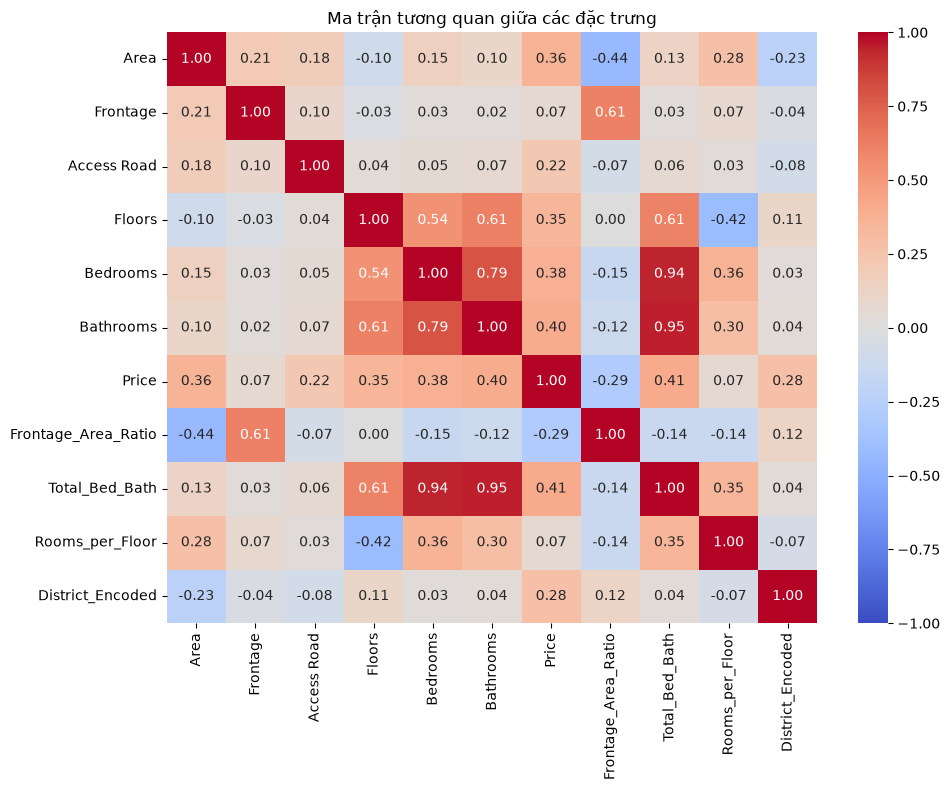

In [17]:
# --------------------------------------------------
# 4. KIỂM TRA TƯƠNG QUAN (BAO GỒM CẢ QUẬN/HUYỆN)
# --------------------------------------------------
# Tạo bản sao encoding tạm thời cho District để xem tương quan với Giá
corr_df = df.copy()
if 'District' in corr_df.columns:
    # Mã hóa Quận/Huyện theo giá trung bình (Target Encoding) để đưa vào ma trận tương quan
    district_map = corr_df.groupby('District')[TARGET_COL].mean()
    corr_df['District_Encoded'] = corr_df['District'].map(district_map)

numeric_df = corr_df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()[TARGET_COL].sort_values(ascending=False)

print("\n--- Mức độ tương quan với Price ---")
print(correlation)

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các đặc trưng')
plt.tight_layout()
plt.show()

In [18]:
# --------------------------------------------------
# 5. CHIA TRAIN/TEST & LOG-TRANSFORM TARGET
# --------------------------------------------------
ignore_cols = [TARGET_COL, 'id', 'date']
X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test : {X_test.shape}")


Kích thước tập Train: (9325, 12)
Kích thước tập Test : (2332, 12)


In [19]:
# --------------------------------------------------
# 6. PIPELINE MÃ HOÁ
# --------------------------------------------------
CAT_COLS = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
NUM_COLS = [c for c in X_train.columns if c not in CAT_COLS]

print(f"\nCột phân loại (Target Encode): {CAT_COLS}")
print(f"Cột số: {NUM_COLS}")

# Xử lý thiếu dữ liệu trước khi mã hoá để tránh lỗi NaN trong cross-validation.
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', cat_imputer),
        ('encoder', TargetEncoder(target_type='continuous'))
    ]), CAT_COLS),
    ('num', Pipeline([
        ('imputer', num_imputer),
        ('scaler', StandardScaler())
    ]), NUM_COLS),
])



Cột phân loại (Target Encode): ['Legal status', 'Furniture state', 'District']
Cột số: ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Frontage_Area_Ratio', 'Total_Bed_Bath', 'Rooms_per_Floor']


In [20]:
# --------------------------------------------------
# 7. ĐỊNH NGHĨA VÀ ĐÁNH GIÁ ĐA MÔ HÌNH (CROSS-VALIDATION)
# --------------------------------------------------
models = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=200, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        ))
    ]),
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
        ))
    ]),
    'CatBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', CatBoostRegressor(
            iterations=300, depth=6, learning_rate=0.05,
            random_state=42, verbose=0, thread_count=1,
            allow_writing_files=False
        ))
    ]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("\n--- Đánh giá Cross-Validation (R2 Score, trên giá đã log-transform) ---")
for name, model_pipe in models.items():
    scores = cross_val_score(model_pipe, X_train, y_train_log, cv=kf, scoring='r2', n_jobs=-1)
    results.append({'Model': name, 'CV R2 Mean': scores.mean(), 'CV R2 Std': scores.std()})
    print(f"• {name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values(by='CV R2 Mean', ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nModel tốt nhất theo CV: {best_model_name}")


--- Đánh giá Cross-Validation (R2 Score, trên giá đã log-transform) ---
• Random Forest: 0.6060 (+/- 0.0110)
• Gradient Boosting: 0.6096 (+/- 0.0163)
• XGBoost: 0.6187 (+/- 0.0127)
• LightGBM: 0.6157 (+/- 0.0112)
• CatBoost: 0.6182 (+/- 0.0187)


,Model,CV R2 Mean,CV R2 Std
2,XGBoost,0.618689,0.012692
4,CatBoost,0.618215,0.018669
3,LightGBM,0.615723,0.011246
1,Gradient Boosting,0.609578,0.016282
0,Random Forest,0.606027,0.011021



Model tốt nhất theo CV: XGBoost


In [21]:
# --------------------------------------------------
# 8. TỐI ƯU HÓA SIÊU THAM SỐ CHO MODEL TỐT NHẤT
# --------------------------------------------------
print(f"\n--- Đang tối ưu hóa siêu tham số cho {best_model_name} ---")

param_grids = {
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [10, 15, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features': ['sqrt', 0.5, 1.0],
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0],
    },
    'XGBoost': {
        'model__n_estimators': [200, 300, 400],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 1.0],
    },
    'LightGBM': {
        'model__n_estimators': [200, 300, 400],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 1.0],
    },
    'CatBoost': {
        'model__iterations': [200, 300, 400],
        'model__depth': [4, 6, 8],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__l2_leaf_reg': [1, 3, 5],
    },
}

best_pipeline = models[best_model_name]
grid = param_grids.get(best_model_name, {})

if grid:
    grid_search = GridSearchCV(
        estimator=best_pipeline,
        param_grid=grid,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train_log)
    best_model = grid_search.best_estimator_
    print("Tham số tối ưu nhất:", grid_search.best_params_)
    print(f"CV R2 tốt nhất: {grid_search.best_score_:.4f}")
    best_cv_score = grid_search.best_score_
else:
    best_pipeline.fit(X_train, y_train_log)
    best_model = best_pipeline
    best_cv_score = results_df.iloc[0]['CV R2 Mean']


--- Đang tối ưu hóa siêu tham số cho XGBoost ---
Tham số tối ưu nhất: {'model__learning_rate': 0.01, 'model__max_depth': 8, 'model__n_estimators': 400, 'model__subsample': 0.8}
CV R2 tốt nhất: 0.6234



--- Kết quả đánh giá trên tập Test (giá trị thật) ---
R2 Score : 0.5568
MAE      : 1.03
RMSE     : 1.34

Chênh lệch CV R2 (0.6234) vs Test R2 (0.5568): 0.0666


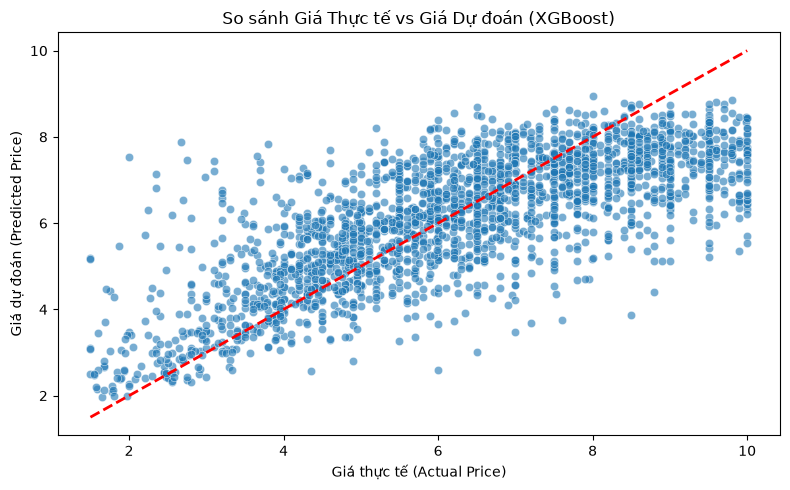

In [22]:
# --------------------------------------------------
# 9. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
# --------------------------------------------------
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Kết quả đánh giá trên tập Test (giá trị thật) ---")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:,.2f}")
print(f"RMSE     : {rmse:,.2f}")
print(f"\nChênh lệch CV R2 ({best_cv_score:.4f}) vs Test R2 ({r2:.4f}): {abs(best_cv_score - r2):.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Giá thực tế (Actual Price)")
plt.ylabel("Giá dự đoán (Predicted Price)")
plt.title(f"So sánh Giá Thực tế vs Giá Dự đoán ({best_model_name})")
plt.tight_layout()
plt.show()

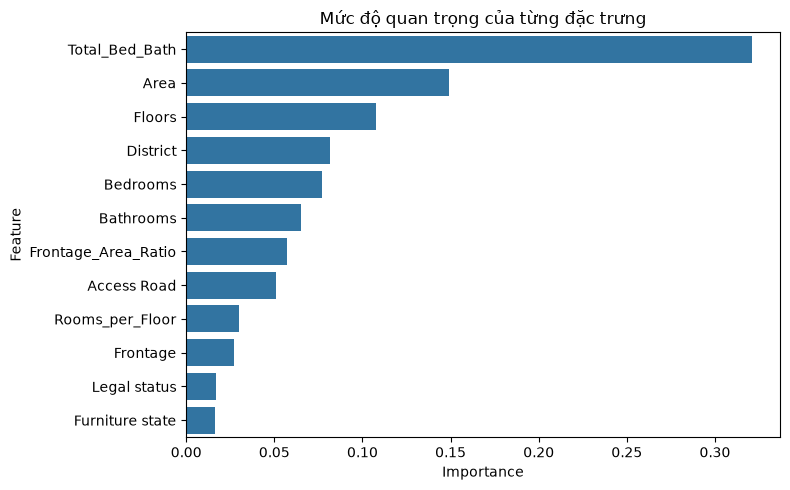

,Feature,Importance
10,Total_Bed_Bath,0.320872
3,Area,0.148987
6,Floors,0.107648
2,District,0.081792
7,Bedrooms,0.077092
8,Bathrooms,0.065351
9,Frontage_Area_Ratio,0.057343
5,Access Road,0.050734
11,Rooms_per_Floor,0.029955
4,Frontage,0.026890



Đã xuất thành công mô hình TỐI ƯU RA: d:\05. CODE\DoAnNganh\RealEstateTrading\ml\models\best_model.pkl
Model được chọn: XGBoost | Test R2: 0.5568


In [ ]:
# --------------------------------------------------
# 10. MỨC ĐỘ QUAN TRỌNG CỦA TỪNG ĐẶC TRƯNG
# --------------------------------------------------
feature_names = CAT_COLS + NUM_COLS
model_step = best_model.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='Importance', y='Feature')
    plt.title('Mức độ quan trọng của từng đặc trưng')
    plt.tight_layout()
    plt.show()

    display(importance_df)
else:
    print(f"\nModel '{best_model_name}' không hỗ trợ feature_importances_.")



In [25]:
# --------------------------------------------------
# 11. LƯU MÔ HÌNH TỐI ƯU
# --------------------------------------------------
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

save_dict = {
    'model': best_model,
    'model_name': best_model_name,
    'feature_names': feature_names,
    'cat_cols': CAT_COLS,
    'num_cols': NUM_COLS,
    'log_transformed': True,
    'test_r2': r2,
    'test_mae': mae,
    'test_rmse': rmse,
}

joblib.dump(save_dict, MODEL_SAVE_PATH)
print(f"\nĐã xuất mô hình tối ưu nhất ra: {MODEL_SAVE_PATH}")
print(f"Model được chọn: {best_model_name} | Test R2: {r2:.4f}")


Đã xuất mô hình tối ưu nhất ra: d:\05. CODE\DoAnNganh\RealEstateTrading\ml\models\best_model.pkl
Model được chọn: XGBoost | Test R2: 0.5568
